# External data through the frozen pipeline: NHANES, UCI CKD, Synthea (notebook 04)

Follow-up to the ε-response problem documented in notebooks 02–03: on the frozen **V1** clinics
the composed privacy budget ε ∈ [0.5, 8] leaves AUROC flat (0.797–0.799) because the V1 generator
is exactly in-class for logistic regression (Bayes = 0.8513 = pooled-logreg ceiling; 200k
Monte-Carlo, see notebook 05 §1). This notebook feeds **three external datasets** through the
*unchanged* pipeline and verifies the same measurement stack behaves sanely on data we did not
generate.

Nothing here edits the repo: all datasets live in new directories (`data/external/`,
`data/clinics_nhanes*/`, `data/clinics_synthea/`, `data/clinics_uci/`), consumed through the
existing `--clinics-dir` / `load_clinic_frames(dir)` interfaces. V1 sits untouched
(`data/VERSIONS.md`, `data/manifest_v1.sha256`).

| Federation | Source | Clinics | Rows | Prevalence |
|---|---|---|---|---|

In [1]:
import sys, json, logging
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings
logging.getLogger('flwr').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)  # dp_accounting subsampled-RDP notes (documented fallback, nb02 does the same)
warnings.filterwarnings('ignore', category=RuntimeWarning)

from data.loader import load_clinic_frames, to_xy, FEATURE_COLS, LABEL_COL

EXTERNAL_DIRS = {
    'nhanes':      'data/clinics_nhanes',      # 8 clinics: cycle x sex, n ~ 2.5-3k
    'nhanes_small': 'data/clinics_nhanes_s',   # same 8 practices, V1-sized subsample
    'synthea':     'data/clinics_synthea',     # 14 clinics: MA county clinics
    'uci':         'data/clinics_uci',         # 1 clinic: Apollo Hospitals 336
    'v2_main':     'data/clinics_v2_main',     # synthetic harder (notebook 05), for reference
    'V1':          'data/clinics',             # frozen compar
}
pd.set_option('display.width', 160)

## 1 · What each mapping does (and costs)

The label everywhere is **CKD stage ≥ 3 prevalence**, matching V1's `ckd_stage3plus` semantics —
not the canonical SQL incidence task. NHANES computes it by the race-free CKD-EPI 2021
creatinine equation (real labs); Synthea by the KDIGO chronicity rule on longitudinal eGFR
observations (two values < 60 ≥ 90 days apart — the same rule `extract_features.sql` encodes);
UCI by its chart-review study label (not stage-graded — the coarsest label of the three).

Honesty notes that any downstream claim on these federations must carry:

- **NHANES's label contains `age_years`** — CKD-EPI computes eGFR from age, sex and creatinine,
  so age (a feature) partially *defines* the label. AUROC ~0.9 here does not mean the model
  learned biology; single-exam NHANES also cannot express the canonical *incidence* task.
- **UCI clinics force structural zeros**: obesity, heart failure, gout and all `years_since_*`
  do not exist in the study ≈ a real-world under-coded record (V2's `undercoding` knob, minus
  the knob).
- **Synthea is a COVID-era Massachusetts sample**; its measurement process (who gets an eGFR)
  is strongly indication-biased, which is why the label uses the chronicity rule rather than
  "any low eGFR" (that version scored prevalence 0.68 — pure selection).

In [2]:
# Mapping audits — what had to be repaired / dropped, per source (from each suite_meta.json).
nh = json.loads((ROOT / 'data/clinics_nhanes/suite_meta.json').read_text())
uci = json.loads((ROOT / 'data/clinics_uci/suite_meta.json').read_text())
sy = json.loads((ROOT / 'data/clinics_synthea/suite_meta.json').read_text())

print('NHANES 2011-2018: participants', nh['n_participants'], '| prevalence', nh['prevalence'])
print(pd.DataFrame(nh['coding_loss'])[['cycle', 'participants_in', 'with_creatinine', 'used']].to_string(index=False))
print("  invalid questionnaire codes per cycle (marked structural-zero):",
      pd.DataFrame([c['invalid_codes'] for c in nh['coding_loss']], index=[c['cycle'] for c in nh['coding_loss']]).to_dict('list'))

print('\nUCI CKD #336: n', uci['n'], '| ckd rate', uci['ckd_rate'], '| audit:', uci['audit']['parse'])
worst_missing = sorted(uci['audit']['numeric_repairs'].items(), key=lambda kv: -kv[1]['missing_share'])[:5]
print('  worst missing columns:', {k: f"{v['missing_share']:.1%}" for k, v in worst_missing})

print('\nSynthea 10k: participants', sy['n_participants'], '| prevalence', sy['prevalence'],
      '| eGFR measured share', sy['egfr_measured_share'])

NHANES 2011-2018: participants 21102 | prevalence 0.0783
 cycle  participants_in  with_creatinine  used
  2011             9756             5107  5107
  2013            10175             5563  5563
  2015             9971             5325  5325
  2017             9254             5107  5107
  invalid questionnaire codes per cycle (marked structural-zero): {'htn': [7, 4, 5, 10], 'dm': [4, 3, 4, 4], 'chf': [279, 303, 245, 253], 'chd': [283, 312, 260, 253], 'gout': [270, 298, 244, 244]}

UCI CKD #336: n 399 | ckd rate 0.6266 | audit: {'trailing_comma_repaired': 2, 'quarantined_rows': [{'line': 515, 'n_fields': 26}]}
  worst missing columns: {'pot': '22.1%', 'sod': '21.8%', 'pcv': '17.8%', 'hemo': '13.0%', 'su': '12.3%'}

Synthea 10k: participants 9844 | prevalence 0.0452 | eGFR measured share 0.3786


## 2 · Distribution contract vs V1

The column-level table notebooks 01–03 never *needed*: how the external federations differ from
V1 on the axes the privacy results depend on. `max|flag corr|` — the comorbidity-independence
property; prevalence spread and panel-size spread — the heterogeneity the strategies average
over; `max|feature-label corr|` — how concentrated the signal is.

In [3]:
def dir_stats(d):
    frames = load_clinic_frames(ROOT / d)
    allX = np.vstack([to_xy(f)[0] for f in frames]); ally = np.concatenate([to_xy(f)[1] for f in frames])
    C = np.corrcoef(allX.T)
    flag_idx = [FEATURE_COLS.index(c) for c in FEATURE_COLS if c.startswith('dx_')]
    Cf = np.abs(C[np.ix_(flag_idx, flag_idx)]); np.fill_diagonal(Cf, 0)
    fl = np.abs([np.corrcoef(allX[:, i], ally)[0, 1] for i in range(allX.shape[1])])
    rates = pd.Series([f[LABEL_COL].mean() for f in frames]); sizes = pd.Series([len(f) for f in frames])
    return {'dir': d.split('/')[-1], 'clinics': len(frames), 'rows': sum(sizes),
            'size range': f'{sizes.min()}-{sizes.max()}',
            'prev range': f'{rates.min():.2f}-{rates.max():.2f}',
            'max|flag corr|': round(float(np.nanmax(Cf)), 3),  # NaN-safe: UCI/Synthea carry constant under-coded flags
            'max|feat-label corr|': round(float(np.nanmax(fl)), 3)}

stats = pd.DataFrame([dir_stats(d) for d in EXTERNAL_DIRS.values()])
stats

,dir,clinics,rows,size range,prev range,max|flag corr|,max|feat-label corr|
0,clinics_nhanes,8,21102,2481-2887,0.07-0.09,0.347,0.351
1,clinics_nhanes_s,8,3015,188-537,0.07-0.11,0.406,0.375
2,clinics_synthea,14,9844,27-2233,0.01-0.08,0.172,0.614
3,clinics_uci,1,399,399-399,0.63-0.63,0.608,0.590
4,clinics_v2_main,10,3379,152-577,0.04-0.47,0.212,0.252
5,clinics,10,3276,161-532,0.08-0.46,0.076,0.361


## 3 · The pipeline runs unmodified

`run_simulation(..., clinics_dir=...)` — the same in-process runner behind `ckd-simulate`,
notebook 01 and the paper tables — on each directory. 10 rounds, seed 42, one seed (display run;
the 5-seed protocol is for the paper runs).

INFO :      aggregate_train: Received 8 results and 0 failures


INFO :      aggregate_evaluate: Received 8 results and 0 failures


INFO :      aggregate_train: Received 8 results and 0 failures


INFO :      aggregate_evaluate: Received 8 results and 0 failures


INFO :      aggregate_train: Received 8 results and 0 failures


...

INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


  round  5: AUROC=0.792 (worst practice 0.657)  sensitivity=0.708
  round  6: AUROC=0.793 (worst practice 0.664)  sensitivity=0.704
  round  7: AUROC=0.794 (worst practice 0.664)  sensitivity=0.707
  round  8: AUROC=0.794 (worst practice 0.679)  sensitivity=0.715
  round  9: AUROC=0.793 (worst practice 0.679)  sensitivity=0.708
  round 10: AUROC=0.795 (worst practice 0.679)  sensitivity=0.708
V1           r10: AUROC=0.795 worst=0.679 sens=0.708


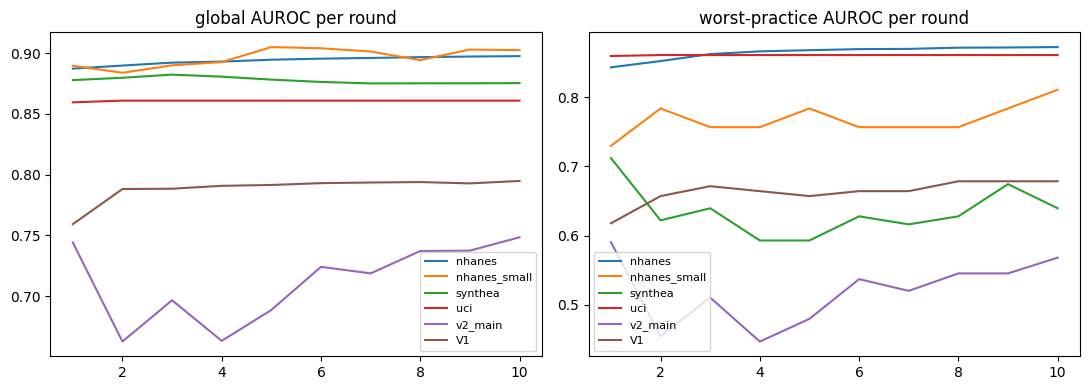

In [4]:
from simulate import run_simulation

histories = {}
for name, d in EXTERNAL_DIRS.items():
    histories[name] = run_simulation(num_practices=25, num_rounds=10, quiet=True,
                                     clinics_dir=str(ROOT / d) if name != 'V1' else True, seed=42)
    h = histories[name]
    print(f"{name:<12} r10: AUROC={h[-1]['auc']:.3f} worst={h[-1]['auc_worst']:.3f} sens={h[-1]['sensitivity']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, h in histories.items():
    ax[0].plot(range(1, len(h)+1), [r['auc'] for r in h], label=name)
    ax[1].plot(range(1, len(h)+1), [r['auc_worst'] for r in h], label=name)
ax[0].set_title('global AUROC per round'); ax[1].set_title('worst-practice AUROC per round')
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4 · Does ε move on real data?

The deployment-standard measurement from notebook 03 — patient-level DP-SGD + SecAgg semantics +
the rule-based orchestrator's per-clinic (batch, σ) plans — re-run on `clinics_nhanes_s`
(V1-sized NHANES practices, so N is comparable). V1's published answer for the same protocol:
flat 0.797–0.799 across ε 0.5–8.

In [5]:
from types import SimpleNamespace
from dpsgd import prepare_practices, run_standard, _cell_seed
from orchestrator import plan as orchestrator_plan

ROUNDS, EPOCHS, LR, SEEDS = 10, 2, 0.5, (42, 43, 44)

def orchestrator_shim(sizes, eps, rounds, epochs):
    """dpsgd.run_epsilon_sweep's documented injection point, with a dict census."""
    return orchestrator_plan({f'clinic_{i}': int(n) for i, n in enumerate(sizes)},
                             target_epsilon=eps, fed_rounds=rounds, epochs=epochs)

def epsilon_response(clinics_dir, epsilons=(None, 0.5, 1.0, 2.0, 4.0, 8.0), seeds=SEEDS):
    frames = load_clinic_frames(ROOT / clinics_dir)
    locals_by_seed = {s: prepare_practices(frames, s) for s in seeds}
    rows = []
    for eps in epsilons:
        sizes = [len(loc.y) for loc in locals_by_seed[seeds[0]]]
        plans = ([SimpleNamespace(batch_size=n, sigma=0.0, clip=1.0, local_epochs=EPOCHS)
                  for n in sizes] if eps is None
                 else orchestrator_shim(sizes, eps, ROUNDS, EPOCHS))
        runs = []
        for s in seeds:
            h = run_standard(locals_by_seed[s], plans, rounds=ROUNDS, lr=LR, seed=_cell_seed(s, eps))
            runs.append({k: h[-1][k] for k in ('auc', 'auc_worst', 'sensitivity')})
        rows.append({'target_epsilon': eps,
                     'auc_mean': np.mean([r['auc'] for r in runs]),
                     'auc_std': np.std([r['auc'] for r in runs]),
                     'auc_worst_mean': np.mean([r['auc_worst'] for r in runs]),
                     'sensitivity_mean': np.mean([r['sensitivity'] for r in runs])})
    return pd.DataFrame(rows)

resp = epsilon_response('data/clinics_nhanes_s')
resp.round(4)

,target_epsilon,auc_mean,auc_std,auc_worst_mean,sensitivity_mean
0,NaN,0.8850,0.0100,0.7901,0.3380
1,0.5,0.8875,0.0170,0.7751,0.2932
2,1.0,0.8910,0.0122,0.7977,0.3016
3,2.0,0.8898,0.0101,0.7875,0.2990
4,4.0,0.8917,0.0107,0.7928,0.2921
5,8.0,0.8912,0.0110,0.7928,0.3130


## 5 · Fairness by sex — the audit V1 could not run

CLAUDE.md live issue 5: the Antrag's T2.5 analysis is specified *by sex*, and the synthetic
schema has no sex column. NHANES has one. One no-DP federation over the full-size NHANES
clinics, then `task.fairness_metrics` on the pooled test scores with `sex_female` as the group.
Test rows are recovered by replaying the same deterministic `_local_split` against the raw
frames (same seeds → identical splits to the training run).

In [6]:
from task import fairness_metrics, fit_scaler
from client_app import _local_split
from models.protocols.common import predict_proba

frames_full = load_clinic_frames(ROOT / 'data/clinics_nhanes')
locals_ = prepare_practices(frames_full, 42)
sizes = [len(loc.y) for loc in locals_]
plans = [SimpleNamespace(batch_size=n, sigma=0.0, clip=1.0, local_epochs=EPOCHS) for n in sizes]
hist, w_final = run_standard(locals_, plans, rounds=ROUNDS, lr=LR, seed=42, keep_final_model=True)
print('no-DP r10: AUROC=%.3f worst=%.3f' % (hist[-1]['auc'], hist[-1]['auc_worst']))

y_all, s_all, g_all = [], [], []
for pid, (frame, loc) in enumerate(zip(frames_full, locals_)):
    # positional test indices from the identical split
    idx_tr, _, idx_te, _ = _local_split(np.arange(len(frame)), np.arange(len(frame)), 42, pid)
    y_all.append(loc.y_test); s_all.append(loc.test_scores(w_final))
    g_all.append(frame['sex_female'].to_numpy()[idx_te])
fm = fairness_metrics(np.concatenate(y_all), np.concatenate(s_all), np.concatenate(g_all))
for k, v in fm.items():
    print(f'{k}: {v:.4f}' if isinstance(v, float) else f'{k}: {v}')

no-DP r10: AUROC=0.864 worst=0.836
demographic_parity_gap: 0.0026
equal_opportunity_gap: 0.0249
equalized_odds_gap: 0.0249
calibration_gap: 0.0045
n_groups: 2.0000


## Reading & take-aways

- The pipeline — loaders, splits, strategies, DP-SGD runner, orchestrator plans — consumed three
  external datasets with **zero code changes**; every directory answers `load_clinic_frames`.
- NHANES AUROC ≈ 0.9 must not be read as "real data is easy": the CKD-EPI label literally embeds
  `age_years` and `sex`. The dataset's value here is its *joint real-world mess* (correlated
  comorbidity, MNAR laboratory subsampling, coding loss), the sex/race columns for T2.5, and 21k
  real patients — not its benchmark difficulty.
- UCI (399 usable rows, one quarantined on-parse) exercises the imputation/messy-realism path
  and nothing else — it is one clinic, by design.
- Synthea gives 14 county-sized clinics with longitudinal durations; the chronicity-rule label
  is the same logic production SQL uses, which makes this federation the closest rehearsal of
  the real `/fhir` data path short of the Synthea→FHIR-server adapter (deliberate follow-up).

The *ε question* itself is answered where it can be answered — on a controlled generator — in
**notebook 05**.